
# Enterprise BI — Exploratory Data Analysis

## TL;DR

This notebook explores revenue, profit, monthly trends, categories and regions.
The main analytical question is why revenue does not translate into profit.


In [1]:

from getpass import getpass
import mysql.connector
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

MYSQL_PASSWORD = getpass("Enter MySQL password: ")

connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password=MYSQL_PASSWORD,
    database="enterprise_bi"
)

print("MySQL connection successful!")


MySQL connection successful!


## Company KPI Summary

In [2]:

company_query = '''
SELECT
    SUM(Revenue) AS Revenue,
    SUM(Discount) AS Discounts,
    SUM(Refunds) AS Refunds,
    SUM(Product_Cost) AS Product_Cost,
    SUM(Shipping_Cost) AS Shipping_Cost,
    SUM(Payment_Fee) AS Payment_Fees,
    SUM(Allocated_Marketing_Cost) AS Marketing_Cost,
    SUM(Net_Profit) AS Net_Profit,
    SUM(Net_Profit) / NULLIF(SUM(Revenue), 0) * 100
        AS Profit_Margin_Percentage,
    COUNT(DISTINCT Order_ID) AS Orders,
    COUNT(DISTINCT Customer_ID) AS Customers
FROM vw_sales_profitability
'''

company_kpis = pd.read_sql(
    company_query,
    connection
)

company_kpis


,Revenue,Discounts,Refunds,Product_Cost,Shipping_Cost,Payment_Fees,Marketing_Cost,Net_Profit,Profit_Margin_Percentage,Orders,Customers
0,"484,259,046.67","14,976,750.82","3,249,066.95","315,095,009.22","15,898,326.00","8,716,623.56","173,750,208.91","-32,450,187.97",-6.70,98637,19755


## Monthly Revenue and Profit Trend

In [3]:

monthly_query = '''
SELECT
    DATE_FORMAT(Sale_Date, '%Y-%m-01') AS Month,
    SUM(Revenue) AS Revenue,
    SUM(Net_Profit) AS Net_Profit,
    SUM(Net_Profit) / NULLIF(SUM(Revenue), 0) * 100
        AS Profit_Margin_Percentage,
    COUNT(DISTINCT Order_ID) AS Orders
FROM vw_sales_profitability
GROUP BY DATE_FORMAT(Sale_Date, '%Y-%m-01')
ORDER BY Month
'''

monthly = pd.read_sql(
    monthly_query,
    connection
)

monthly["Month"] = pd.to_datetime(
    monthly["Month"]
)

monthly


,Month,Revenue,Net_Profit,Profit_Margin_Percentage,Orders
0,2025-09-01,"39,791,568.46","-2,656,020.26",-6.67,12152
1,2025-10-01,"40,177,053.89","-2,759,209.23",-6.87,12420
2,2025-11-01,"39,831,108.90","-2,675,185.16",-6.72,12156
3,2025-12-01,"40,651,035.41","-2,729,090.65",-6.71,12417
4,2026-01-01,"41,120,136.11","-2,762,859.64",-6.72,12432
5,2026-02-01,"37,632,258.54","-2,507,238.09",-6.66,11617
6,2026-03-01,"40,692,032.60","-2,739,583.17",-6.73,12428
7,2026-04-01,"39,815,158.25","-2,663,791.31",-6.69,12158
8,2026-05-01,"41,069,786.96","-2,746,815.47",-6.69,12431
9,2026-06-01,"39,848,982.24","-2,675,940.97",-6.72,12157


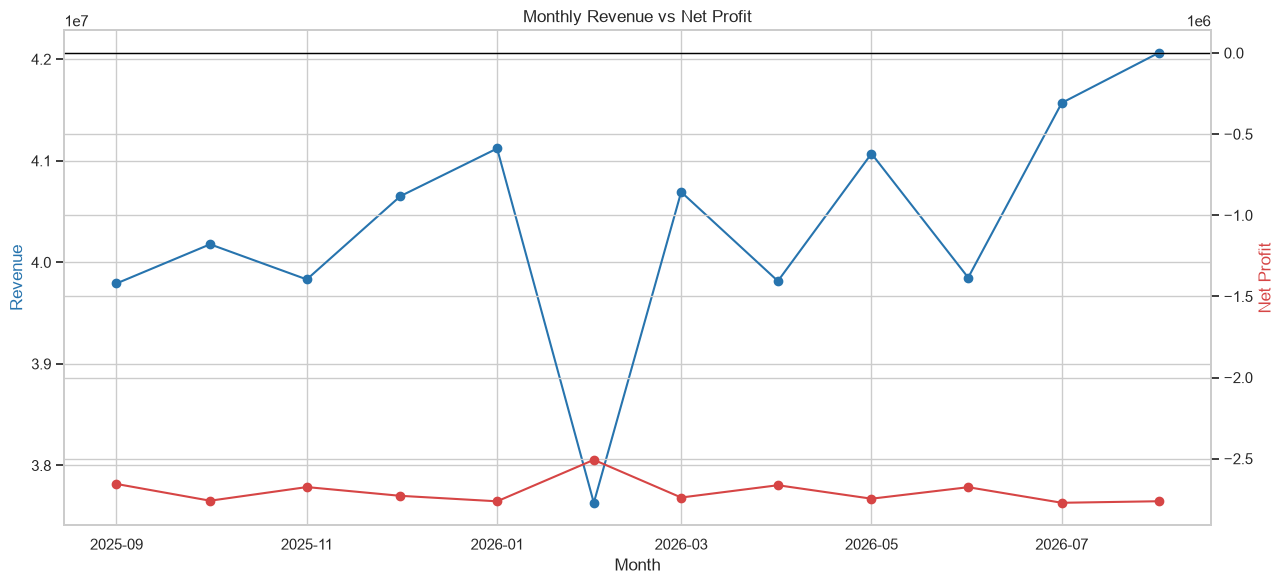

In [4]:

fig, first_axis = plt.subplots(
    figsize=(13, 6)
)

first_axis.plot(
    monthly["Month"],
    monthly["Revenue"],
    marker="o",
    color="#2774AE",
    label="Revenue"
)

first_axis.set_xlabel("Month")
first_axis.set_ylabel("Revenue", color="#2774AE")

second_axis = first_axis.twinx()

second_axis.plot(
    monthly["Month"],
    monthly["Net_Profit"],
    marker="o",
    color="#D64545",
    label="Net Profit"
)

second_axis.axhline(
    0,
    color="black",
    linewidth=1
)

second_axis.set_ylabel(
    "Net Profit",
    color="#D64545"
)

plt.title(
    "Monthly Revenue vs Net Profit"
)

fig.tight_layout()
plt.show()


## Category Performance

In [5]:

category_query = '''
SELECT
    Category,
    SUM(Quantity) AS Units_Sold,
    SUM(Revenue) AS Revenue,
    SUM(Net_Profit) AS Net_Profit,
    SUM(Net_Profit) / NULLIF(SUM(Revenue), 0) * 100
        AS Profit_Margin_Percentage
FROM vw_sales_profitability
GROUP BY Category
ORDER BY Revenue DESC
'''

category = pd.read_sql(
    category_query,
    connection
)

category


,Category,Units_Sold,Revenue,Net_Profit,Profit_Margin_Percentage
0,Accessories,"125,157.00","82,690,176.54","-5,542,869.47",-6.70
1,Electronics,"123,561.00","81,711,714.29","-5,473,013.74",-6.70
2,Home Appliances,"124,871.00","80,841,416.68","-5,406,681.14",-6.69
3,IT Equipment,"124,286.00","80,686,012.37","-5,367,264.51",-6.65
4,Office Supplies,"122,362.00","80,456,992.82","-5,402,642.39",-6.71
5,Furniture,"121,119.00","77,872,733.97","-5,257,716.72",-6.75


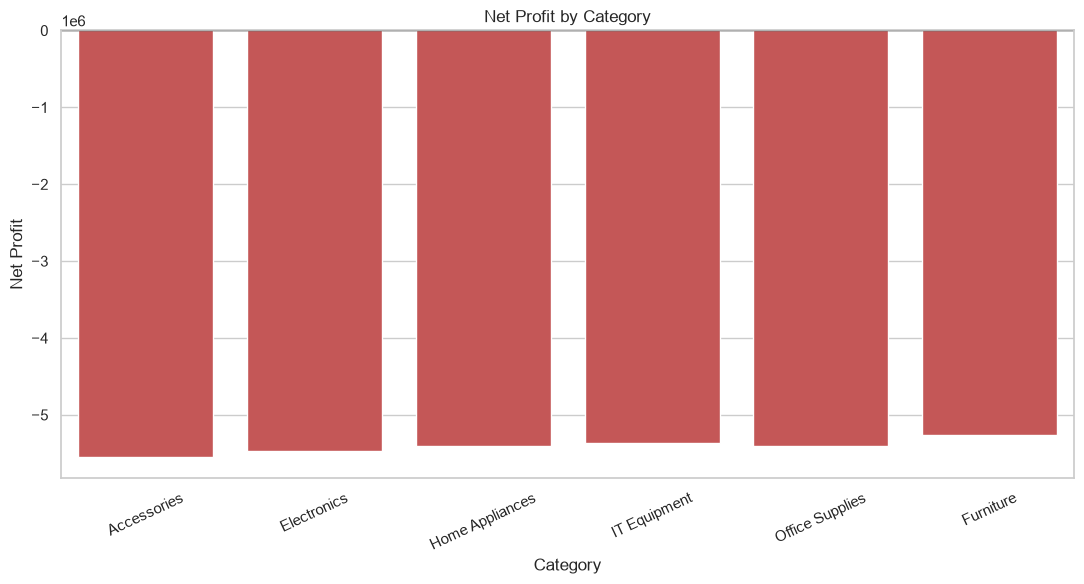

In [6]:

plt.figure(figsize=(11, 6))

sns.barplot(
    data=category,
    x="Category",
    y="Net_Profit",
    color="#D64545"
)

plt.axhline(
    0,
    color="black",
    linewidth=1
)

plt.title("Net Profit by Category")
plt.xlabel("Category")
plt.ylabel("Net Profit")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


## Regional Performance

In [7]:

region_query = '''
SELECT
    Region_ID,
    MAX(Region_Name) AS Region_Name,
    SUM(Revenue) AS Revenue,
    SUM(Net_Profit) AS Net_Profit,
    SUM(Net_Profit) / NULLIF(SUM(Revenue), 0) * 100
        AS Profit_Margin_Percentage
FROM vw_sales_profitability
GROUP BY Region_ID
ORDER BY Profit_Margin_Percentage
'''

region = pd.read_sql(
    region_query,
    connection
)

connection.close()

region


,Region_ID,Region_Name,Revenue,Net_Profit,Profit_Margin_Percentage
0,R006,North,"7,339,212.26","-1,105,437.90",-15.06
1,R001,North,"6,429,104.79","-955,689.89",-14.87
2,R011,North,"7,783,112.43","-1,154,983.99",-14.84
3,R016,North,"8,864,294.16","-1,302,387.42",-14.69
4,R002,South,"13,177,450.13","-1,165,642.87",-8.85
5,R012,South,"16,520,196.02","-1,448,683.76",-8.77
6,R017,South,"17,560,252.89","-1,537,473.63",-8.76
7,R007,South,"14,910,458.09","-1,288,642.78",-8.64
8,R018,East,"26,659,614.99","-1,828,122.64",-6.86
9,R003,East,"20,617,976.71","-1,412,533.87",-6.85


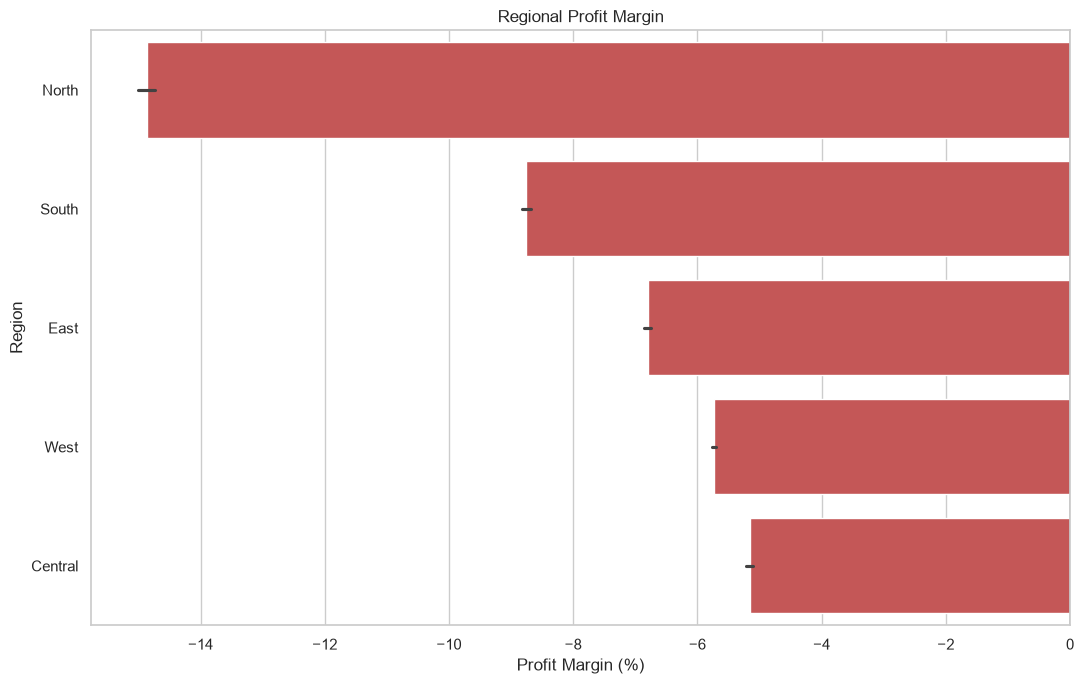

In [8]:

plt.figure(figsize=(11, 7))

sns.barplot(
    data=region,
    y="Region_Name",
    x="Profit_Margin_Percentage",
    color="#D64545"
)

plt.axvline(
    0,
    color="black",
    linewidth=1
)

plt.title("Regional Profit Margin")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Region")
plt.tight_layout()
plt.show()



## Takeaways

- Revenue remains near ₹4 crore per month, but profit is negative throughout.
- Every category and region is loss-making.
- The loss is structural rather than isolated to one product or month.
- Product cost and marketing allocation are the largest cost drivers.
